In [ ]:
!pip install numpy pandas transformers datasets scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 316.1/316.1 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.9/39.9 MB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 15.6 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.6.1
    Uninstalling fsspec-2024.6.1:
    

In [ ]:
import numpy as np
import pandas as pd
from transformers import BertTokenizer, Trainer, BertForSequenceClassification, TrainingArguments
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
torch.cuda.is_available()

True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
csv_path = "/content/drive/MyDrive/FinancialPhraseBank-v1.0/all-data.csv"

df = pd.read_csv(csv_path, encoding='latin1')

# Print the shape and column names
print(df.shape)
df.columns = ["label", "text"]
print(df.head())

(4845, 2)
      label                                               text
0   neutral  Technopolis plans to develop in stages an area...
1  negative  The international electronic industry company ...
2  positive  With the new production plant the company woul...
3  positive  According to the company 's updated strategy f...
4  positive  FINANCING OF ASPOCOMP 'S GROWTH Aspocomp is ag...


In [ ]:
from datasets import Dataset, DatasetDict, concatenate_datasets

In [ ]:
d={'positive':0,'negative':1,'neutral':2}
df.label=df.label.replace(d)
df.head(2)

,label,text
0,2,Technopolis plans to develop in stages an area...
1,1,The international electronic industry company ...


In [ ]:
dataset = Dataset.from_pandas(df[['label','text']])

In [ ]:
ds = dataset.train_test_split(test_size=0.2,seed=42)
ds

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 3876
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 969
    })
})

In [ ]:
df['label'] = df['label'].astype(int)
dataset2 = Dataset.from_pandas(df[['label','text']])
df['text'] = df['text'].astype(str)

In [ ]:
dataset2 = Dataset.from_pandas(df[['label', 'text']])

# Load the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Tokenize the dataset with padding and truncation
def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True)

tokenized_datasets2 = dataset2.map(tokenize_function, batched=True)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Map:   0%|          | 0/4845 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets2.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

In [ ]:
model2 = '/content/drive/MyDrive/VibeValue3'
from transformers import AutoModelForSequenceClassification,AutoTokenizer

In [ ]:
model_nm = 'yiyanghkust/finbert-pretrain'
from transformers import AutoModelForSequenceClassification,AutoTokenizer
tokz = AutoTokenizer.from_pretrained(model_nm)

config.json:   0%|          | 0.00/359 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/226k [00:00<?, ?B/s]

In [ ]:
def tok_func(x):
    return tokz(x["text"],padding=True,truncation=True,max_length=128,return_tensors="pt")
tok_ds = ds.map(tok_func, batched=True)
tok_ds = tok_ds.remove_columns('text')
tok_ds

Map:   0%|          | 0/3876 [00:00<?, ? examples/s]

Map:   0%|          | 0/969 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3876
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 969
    })
})

In [ ]:
df_train, df_test, = train_test_split(df, stratify=df['label'], test_size=0.1, random_state=42)
df_train, df_val = train_test_split(df_train, stratify=df_train['label'],test_size=0.1, random_state=42)
print(df_train.shape, df_test.shape, df_val.shape)

(3924, 2) (485, 2) (436, 2)


In [ ]:
model_2 = AutoModelForSequenceClassification.from_pretrained(model2, num_labels=3)

In [ ]:
ds = dataset.train_test_split(test_size=0.2,seed=42)
ds
bs = 32
lr = 2e-5
epochs = 20

In [ ]:
from transformers import TrainingArguments

args = TrainingArguments(
    'outputs',
    learning_rate=lr,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    fp16=True,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=bs,
    per_device_eval_batch_size=bs * 4,
    weight_decay=0.01,
    report_to='none',
    num_train_epochs=epochs,
    load_best_model_at_end=True,
    logging_strategy='epoch'
)

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1494: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall}

In [ ]:
trainer2 = Trainer(model_2, args, train_dataset=tok_ds['train'], eval_dataset=tok_ds['test'],
                  tokenizer=tokz,compute_metrics=compute_metrics)

In [ ]:
trainer2.train();

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.320500,0.253909,0.901961,0.888120,0.881522,0.895854
2,0.231300,0.294318,0.890609,0.875934,0.865177,0.889389
3,0.146100,0.313507,0.897833,0.883991,0.881871,0.886503
4,0.079500,0.425084,0.889577,0.878694,0.875264,0.886123
5,0.054900,0.450682,0.893705,0.877775,0.872293,0.883642
6,0.032800,0.556982,0.888545,0.874357,0.861863,0.888979
7,0.022200,0.569506,0.894737,0.879649,0.874333,0.886255
8,0.014300,0.644817,0.892673,0.878014,0.877526,0.879520
9,0.018700,0.666136,0.892673,0.880853,0.872923,0.890250
10,0.010200,0.636315,0.892673,0.875044,0.877616,0.872828


In [ ]:
trainer2.evaluate()

{'eval_loss': 0.25390926003456116,
 'eval_accuracy': 0.9019607843137255,
 'eval_f1': 0.888119500032825,
 'eval_precision': 0.8815217694183212,
 'eval_recall': 0.8958541335255154,
 'eval_runtime': 1.1775,
 'eval_samples_per_second': 822.931,
 'eval_steps_per_second': 6.794,
 'epoch': 20.0}

In [ ]:
trainer2.save_model('/content/drive/MyDrive/VibeValue4')

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# # Example true labels and predicted labels
# y_true = [0, 1, 2, 2, 0, 1]
# y_pred = [0, 2, 1, 2, 0, 1]

# # Generate confusion matrix
# cm = confusion_matrix(y_true, y_pred)

# # Plot confusion matrix
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
# disp.plot(cmap=plt.cm.Blues)
# plt.show()


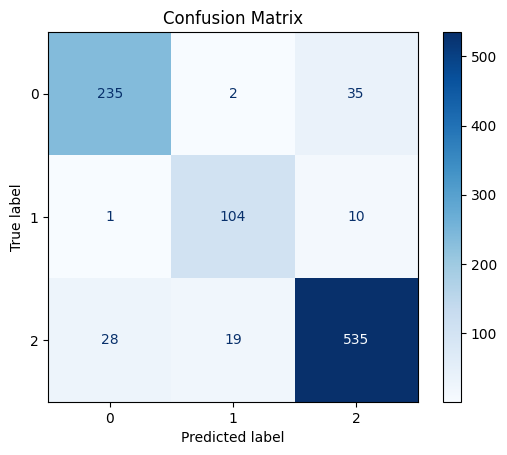

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Make predictions on the test set
predictions = trainer2.predict(tok_ds['test'])

# Extract true labels and predicted labels
y_true = predictions.label_ids
y_pred = np.argmax(predictions.predictions, axis=1)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()
